In [9]:
# Cell 1: Install Required Libraries
"""
Install DeepFace library for face verification
"""
!pip install deepface

In [10]:
# Cell 2: Import Libraries
"""
Import necessary libraries
"""
from deepface import DeepFace
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import os

In [11]:

# Cell 3: Sample Images

anchor_path = "anchor.jpg"
positive_path = "positive.jpg"
negative_path = "negative.jpg"

if os.path.exists(anchor_path) and os.path.exists(positive_path) and os.path.exists(negative_path):
    print("✅ All images found!")
else:
    print("\n⚠️ Images not found. Please upload:")
    if not os.path.exists(anchor_path):
        print("  ✗ anchor.jpg")
    if not os.path.exists(positive_path):
        print("  ✗ positive.jpg")
    if not os.path.exists(negative_path):
        print("  ✗ negative.jpg")
    print("\n💡 TIP: Upload images using the file upload button in your notebook")


✅ All images found!


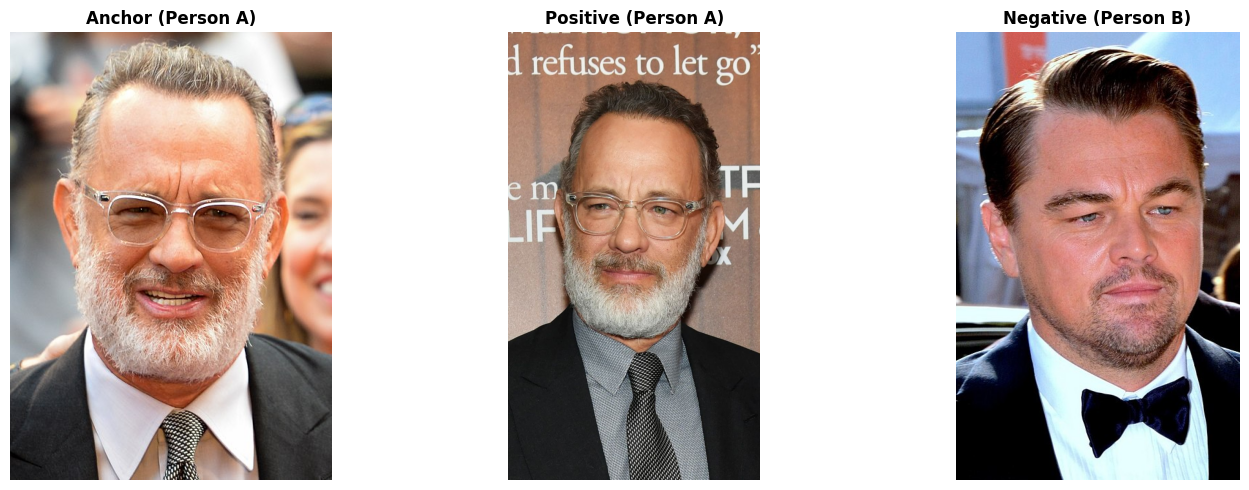

In [12]:
# Cell 4: Display Downloaded Images
"""
Visualize the downloaded images
"""
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

images = [anchor_path, positive_path, negative_path]
titles = ["Anchor (Person A)", "Positive (Person A)", "Negative (Person B)"]

for ax, img_path, title in zip(axes, images, titles):
    if img_path:
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# Cell 5: Face Verification - Positive Case
"""
Compare Anchor vs Positive (Same Person)
Expected: Verified = True
"""
print("=" * 60)
print("TEST 1: Anchor vs Positive (Same Person)")
print("=" * 60)

try:
    result1 = DeepFace.verify(
        img1_path=anchor_path,
        img2_path=positive_path,
        model_name='Facenet',
        distance_metric='cosine'
    )

    print(f"\n✓ Verification Result: {result1['verified']}")
    print(f"✓ Distance (Cosine): {result1['distance']:.4f}")
    print(f"✓ Threshold: {result1['threshold']:.4f}")

    if result1['verified']:
        print("\n✅ SUCCESS: Same person verified!")
    else:
        print("\n⚠️ WARNING: Should be verified but returned False")

except Exception as e:
    print(f"\n✗ Error in verification: {e}")


TEST 1: Anchor vs Positive (Same Person)

✓ Verification Result: True
✓ Distance (Cosine): 0.1953
✓ Threshold: 0.4000

✅ SUCCESS: Same person verified!


In [14]:
# Cell 6: Face Verification - Negative Case
"""
Compare Anchor vs Negative (Different People)
Expected: Verified = False
"""
print("\n" + "=" * 60)
print("TEST 2: Anchor vs Negative (Different People)")
print("=" * 60)

try:
    result2 = DeepFace.verify(
        img1_path=anchor_path,
        img2_path=negative_path,
        model_name='Facenet',
        distance_metric='cosine'
    )

    print(f"\n✓ Verification Result: {result2['verified']}")
    print(f"✓ Distance (Cosine): {result2['distance']:.4f}")
    print(f"✓ Threshold: {result2['threshold']:.4f}")

    if not result2['verified']:
        print("\n✅ SUCCESS: Different people correctly identified!")
    else:
        print("\n⚠️ WARNING: Should be False but returned True")

except Exception as e:
    print(f"\n✗ Error in verification: {e}")



TEST 2: Anchor vs Negative (Different People)

✓ Verification Result: False
✓ Distance (Cosine): 0.9304
✓ Threshold: 0.4000

✅ SUCCESS: Different people correctly identified!


In [15]:
# Cell 7: Compare with Euclidean Distance
"""
Optional: Compare results using Euclidean distance metric
"""
print("\n" + "=" * 60)
print("BONUS: Comparison with Euclidean Distance")
print("=" * 60)

try:
    # Same person - Euclidean
    result3 = DeepFace.verify(
        img1_path=anchor_path,
        img2_path=positive_path,
        model_name='Facenet',
        distance_metric='euclidean'
    )

    print(f"\nSame Person (Euclidean):")
    print(f"  Verified: {result3['verified']}")
    print(f"  Distance: {result3['distance']:.4f}")

    # Different people - Euclidean
    result4 = DeepFace.verify(
        img1_path=anchor_path,
        img2_path=negative_path,
        model_name='Facenet',
        distance_metric='euclidean'
    )

    print(f"\nDifferent People (Euclidean):")
    print(f"  Verified: {result4['verified']}")
    print(f"  Distance: {result4['distance']:.4f}")

except Exception as e:
    print(f"\n✗ Error: {e}")



BONUS: Comparison with Euclidean Distance

Same Person (Euclidean):
  Verified: True
  Distance: 8.0092

Different People (Euclidean):
  Verified: False
  Distance: 17.3551


In [17]:
# Cell 8: Summary Report
"""
Generate a summary of all verification results
"""
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

summary_data = [
    ["Test Case", "Metric", "Verified", "Distance"],
    ["-" * 20, "-" * 10, "-" * 10, "-" * 10],
    ["Same Person", "Cosine", str(result1['verified']), f"{result1['distance']:.4f}"],
    ["Different People", "Cosine", str(result2['verified']), f"{result2['distance']:.4f}"],
    ["Same Person", "Euclidean", str(result3['verified']), f"{result3['distance']:.4f}"],
    ["Different People", "Euclidean", str(result4['verified']), f"{result4['distance']:.4f}"],
]

for row in summary_data:
    print(f"{row[0]:<20} {row[1]:<10} {row[2]:<10} {row[3]:<10}")




FINAL SUMMARY
Test Case            Metric     Verified   Distance  
-------------------- ---------- ---------- ----------
Same Person          Cosine     True       0.1953    
Different People     Cosine     False      0.9304    
Same Person          Euclidean  True       8.0092    
Different People     Euclidean  False      17.3551   
